# Feature Selection

In [1]:
from sklearn.linear_model import Lasso
from catboost import CatBoostRegressor, Pool
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import optuna
import warnings
import numpy as np
import json
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

c:\Users\kuday\OneDrive\Документы\learning ml\Диплом\demand predict - clean\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the processed training and testing datasets
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze('columns')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze('columns')

In [4]:
# Weighted Absolute Percentage Error (WAPE) function
def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        return 0.0
    result = np.sum(np.abs(y_true - y_pred)) / denominator

    if np.isnan(result) or np.isinf(result):
        return 1.0  
    return result

wape_scorer = make_scorer(wape, greater_is_better=False)

## Feature selection for linear models

In [5]:
# Objective function for Optuna to optimize Lasso hyperparameters
def objective_lasso(trial):
    alpha = trial.suggest_float('alpha', 0.001, 100.0, log=True)
    max_iter = trial.suggest_int('max_iter', 1000, 10000)
    
    lasso = Lasso(alpha=alpha, max_iter=max_iter, random_state=42)
    
    tscv = TimeSeriesSplit(n_splits=5)

    scores = cross_val_score(
        lasso,
        X_train,
        y_train,
        cv=tscv,
        scoring=wape_scorer,
        n_jobs=-1
    )
    
    return -scores.mean()
study_lasso = optuna.create_study(direction='minimize')
study_lasso.optimize(objective_lasso, n_trials=50)
print(f'Best alpha: {study_lasso.best_params["alpha"]}')
print(f'Best CV WAPE: {study_lasso.best_value}')

[I 2026-05-02 17:07:01,713] A new study created in memory with name: no-name-5cbb804f-811d-41c3-b5e9-ad573d8d16b8
[I 2026-05-02 17:07:04,187] Trial 0 finished with value: 0.12139559515731779 and parameters: {'alpha': 33.80943234581242, 'max_iter': 9424}. Best is trial 0 with value: 0.12139559515731779.
[I 2026-05-02 17:07:06,029] Trial 1 finished with value: 0.12485491219804683 and parameters: {'alpha': 6.49868101794479, 'max_iter': 9206}. Best is trial 0 with value: 0.12139559515731779.
[I 2026-05-02 17:07:07,588] Trial 2 finished with value: 0.13245474081541725 and parameters: {'alpha': 0.06594776083931207, 'max_iter': 2466}. Best is trial 0 with value: 0.12139559515731779.
[I 2026-05-02 17:07:07,634] Trial 3 finished with value: 0.13070701383516142 and parameters: {'alpha': 0.8724109238537128, 'max_iter': 8195}. Best is trial 0 with value: 0.12139559515731779.
[I 2026-05-02 17:07:07,671] Trial 4 finished with value: 0.1224692182609525 and parameters: {'alpha': 9.63979599758777, 'max

Best alpha: 24.350911202107362
Best CV WAPE: 0.1198064408008579


In [6]:
# Train the Lasso model with the best hyperparameters
Lasso = Lasso(**study_lasso.best_params, random_state=42)
Lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",24.350911202107362
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",8300
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [7]:
# Create a DataFrame to display the coefficients of the Lasso model
lasso_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': Lasso.coef_,
    'Absolute_Coefficient': np.abs(Lasso.coef_)
}).sort_values(by='Absolute_Coefficient', ascending=False)
lasso_coef

,Feature,Coefficient,Absolute_Coefficient
21,expanding_std,219.917687,219.917687
13,residual_lag1,158.575200,158.575200
32,is_may_slowdown,-99.825141,99.825141
38,is_q2_low,-67.178293,67.178293
41,is_may_holidays,55.228586,55.228586
26,diff_3,52.095899,52.095899
30,is_main_hiring_peak,30.749072,30.749072
42,is_nauryz_week,-26.362529,26.362529
31,is_summer_hiring_peak,23.212996,23.212996
35,is_early_summer_recovery,-21.588277,21.588277


In [8]:
# Select features with non-zero coefficients and save to JSON
best_linear_features = lasso_coef[lasso_coef['Absolute_Coefficient'] > 0]['Feature'].tolist()
with open('../configs/linear_features.json', 'w') as f:
    json.dump(best_linear_features, f)

## Feature Selection for Tree-based models

In [9]:
# Split the training data into a shorter training set and a validation set for CatBoost feature selection
split_idx = int(len(X_train) * 0.8)

X_train_short, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_train_short, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

train_pool = Pool(X_train_short, y_train_short)
val_pool = Pool(X_val,y_val)

In [10]:
# Initialize the CatBoostRegressor with basic parameters
model = CatBoostRegressor(iterations=500, learning_rate=0.05, verbose=0)
# Perform feature selection using RecursiveByShapValues algorithm to find the optimal number of features to select based on validation performance
summary = model.select_features(
    train_pool,
    eval_set=val_pool,
    features_for_select=list(range(X_train.shape[1])),
    num_features_to_select=1,  
    algorithm='RecursiveByShapValues',
    train_final_model=False,   
    logging_level='Silent',
)

loss_graph = summary['loss_graph']
steps  = np.array(loss_graph['removed_features_count'])
scores = np.array(loss_graph['loss_values'])

best_step = np.argmin(scores)
optimal_n_remove = steps[best_step]
optimal_n_select = X_train.shape[1] - optimal_n_remove

print(f"Remove: {optimal_n_remove}, Leave: {optimal_n_select}")

Remove: 5, Leave: 40


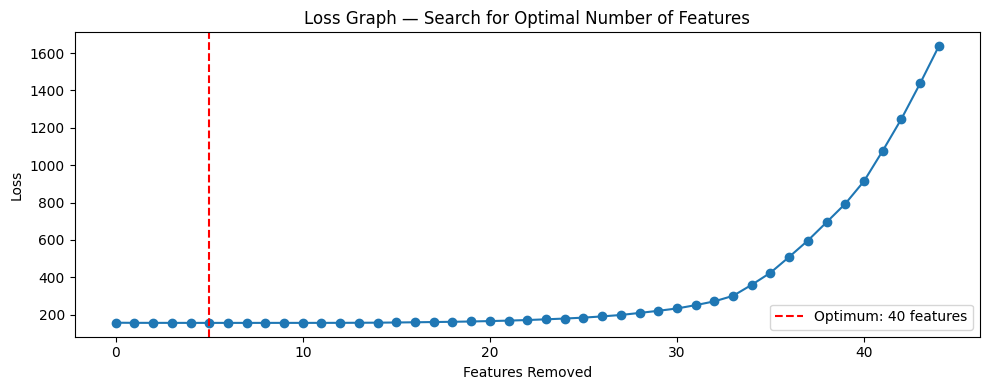

In [11]:
# Visualize the loss graph to identify the optimal number of features to select
plt.figure(figsize=(10, 4))
plt.plot(steps, scores, marker='o')
plt.axvline(optimal_n_remove, color='red', linestyle='--', label=f'Optimum: {optimal_n_select} features')
plt.xlabel('Features Removed')
plt.ylabel('Loss')
plt.title('Loss Graph — Search for Optimal Number of Features')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Final feature selection using the optimal number of features identified from the loss graph
model2 = CatBoostRegressor(iterations=1000, learning_rate=0.05, verbose=0)

summary_final = model2.select_features(
    train_pool,
    eval_set=val_pool,
    features_for_select=list(range(X_train.shape[1])),
    num_features_to_select=optimal_n_select,  
    algorithm='RecursiveByShapValues',
    train_final_model=False,                 
    logging_level='Silent',
    steps=5
)

selected_features = summary_final['selected_features_names']
print(f"Selected: {len(selected_features)} features")
print(selected_features)

Selected: 40 features
['is_month_start', 'week_of_year', 'is_quarter_start', 'is_quarter_end', 'week_sin', 'week_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'rolling_mean_2', 'rolling_mean_4', 'residual_lag2', 'rolling_std_2', 'rolling_std_4', 'ewm_0.1', 'ewm_0.5', 'ewm_0.9', 'expanding_mean', 'expanding_std', 'expanding_max', 'expanding_min', 'diff_1', 'diff_2', 'pct_change_1', 'pct_change_2', 'is_main_hiring_peak', 'is_summer_hiring_peak', 'is_may_slowdown', 'is_december_slowdown', 'is_post_peak_spring', 'is_early_summer_recovery', 'is_stable_plateau', 'is_q1_peak', 'is_q2_low', 'is_new_year_holidays', 'is_may_holidays', 'is_nauryz_week', 'is_graduation_season', 'job_title_unified']


In [13]:
# Save the selected features from CatBoost to a JSON file
with open('../configs/tree_features.json', 'w') as f:
    json.dump(selected_features, f)